sept 11th update

In [4]:
# import xarray as xr
from scipy.interpolate import NearestNDInterpolator
from scipy.interpolate import griddata
import pandas as pd
import numpy as np
# from scipy.spatial import cKDTree
import geopandas as gpd

In [5]:
dt = pd.read_csv("..\\data\\age_hf\\lat_long_age.csv", header=None, skiprows=1,
                 names=['lat', 'long', 'age'])
print(dt)

        lat    long       age
0     49.62 -129.98  0.816961
1     44.68 -125.29  9.119624
2     44.66 -125.27  9.119624
3     44.66 -125.27  9.119624
4     44.66 -125.26  9.119624
...     ...     ...       ...
7440  48.97 -122.10  9.284931
7441  48.97 -122.10  9.284931
7442  48.96 -122.09  9.284931
7443  51.92 -129.97  0.549429
7444  53.56 -131.43  7.047305

[7445 rows x 3 columns]


grav!

In [6]:
dg = pd.read_csv("..\\created_data\\FA.csv", header=None, skiprows=1, names=['long', 'lat', 'FA'])
print(dg)

             long        lat          FA
0     -133.000003  37.983334  -20.522749
1     -133.000003  38.100001  -24.824638
2     -133.000003  38.216667  -31.192137
3     -133.000003  38.333334  -38.186611
4     -133.000003  38.450001  -32.169643
...           ...        ...         ...
16693 -119.000003  53.500001  111.308601
16694 -119.000003  53.616668   50.057011
16695 -119.000003  53.733334   37.020630
16696 -119.000003  53.850001    4.265869
16697 -119.000003  53.966668  -10.105060

[16698 rows x 3 columns]


interpolate age at each grav point (bc we have more grav than thick)

In [7]:
age_interp = griddata((dt[['long','lat']].values), dt['age'].values, dg[['long','lat']].values, method='linear')
age_nan_fill = griddata((dt[['long','lat']].values), dt['age'].values, dg[['long','lat']].values, method='nearest')

dg['age'] = np.where(np.isnan(age_interp), age_nan_fill, age_interp)

print(dg)

             long        lat          FA        age
0     -133.000003  37.983334  -20.522749  33.939312
1     -133.000003  38.100001  -24.824638  33.939312
2     -133.000003  38.216667  -31.192137  33.939312
3     -133.000003  38.333334  -38.186611  33.939312
4     -133.000003  38.450001  -32.169643  33.939312
...           ...        ...         ...        ...
16693 -119.000003  53.500001  111.308601   8.448711
16694 -119.000003  53.616668   50.057011   8.448711
16695 -119.000003  53.733334   37.020630   8.448711
16696 -119.000003  53.850001    4.265869   8.448711
16697 -119.000003  53.966668  -10.105060   8.448711

[16698 rows x 4 columns]


double check no nan

In [8]:
np.where(np.isnan(dg))

(array([], dtype=int64), array([], dtype=int64))

In [9]:
dg[np.isclose(dg['age'], 0.81696, atol=0.0005)]  

,long,lat,FA,age
3688,-129.96667,49.650001,2.029732,0.816997


now bringing in heat flow

In [10]:
dq = pd.read_csv("..\\data\\age_hf\\ihfc_lat_long_q.csv", header=None,
                 names=['lat', 'long', 'q_ihfc'])
print(dq)

        lat    long  q_ihfc
0     49.62 -129.98   366.0
1     44.68 -125.29    79.0
2     44.66 -125.27    81.0
3     44.66 -125.27    93.0
4     44.66 -125.26    77.0
...     ...     ...     ...
7463  48.97 -122.10   100.0
7464  48.97 -122.10    54.0
7465  48.96 -122.09   113.0
7466  51.92 -129.97    45.0
7467  53.56 -131.43    60.0

[7468 rows x 3 columns]


In [11]:
q_interp = griddata((dq[['long','lat']].values), dq['q_ihfc'].values, dg[['long','lat']].values, method='linear')
q_nan_fill = griddata((dq[['long','lat']].values), dq['q_ihfc'].values, dg[['long','lat']].values, method='nearest')

dg['q_ihfc'] = np.where(np.isnan(q_interp), q_nan_fill, q_interp)

print(dg[3688:3689])

           long        lat        FA       age      q_ihfc
3688 -129.96667  49.650001  2.029732  0.816997  345.107451


In [12]:
ps_q = []
stein_q = []
z_ps = []
z_stein = []

i double checked the values in excel

In [13]:
# pars-scl
for a in dg['age']:
    z_ps.append(2500 + 350*(a**(0.5)))
    ps_q.append((11.3/(a**(0.5)))*41.868)  # μcal/cm^2*s --> mW/m^2

# stein x2
for a in dg['age']:
    z_stein.append(2600+365*a**2)
    stein_q.append((510/a**(0.5)))

print(f'age: {dg['age'][3688:3689].values}')
print(f'pars-scl depth: {z_ps[3688:3689]}, stein depth: {z_stein[3688:3689]}')
print(f'pars-scl heat flow: {ps_q[3688:3689]}, stein heat flow: {stein_q[3688:3689]}')

age: [0.81699702]
pars-scl depth: [2816.357605417211], stein depth: [2843.6317055364157]
pars-scl heat flow: [523.4201333064951], stein heat flow: [564.2348941306316]


In [14]:
dg['q_ps'] = ps_q
dg['q_stein'] = stein_q

dg['ps_z'] = z_ps
dg['stein_z'] = z_stein

In [15]:
dg[np.isclose(dg['age'], 0.81696, atol=0.0005)]  

,long,lat,FA,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
3688,-129.96667,49.650001,2.029732,0.816997,345.107451,523.420133,564.234894,2816.357605,2843.631706


In [16]:
dg.shape

(16698, 9)

now bringing in bathy but constraining to gravity size just for now aka aug 14. also bc not enough points to constrain to bathy surely because there is like over a million

In [17]:
db = pd.read_csv("..\\created_data\\gebco_bath.csv", header=None, skiprows=1,
                 names=['long', 'lat', 'bathy'])

db.shape

(11059200, 3)

In [18]:
db = db.iloc[::5]  # keeps 1 in every 5 rows, gebco super huge
print(db.shape)

(2211840, 3)


In [19]:
bath_interp = griddata((db[['long','lat']].values), db['bathy'].values, dg[['long','lat']].values, method='linear')

In [20]:
bath_nan_fill = griddata((db[['long','lat']].values), db['bathy'].values, dg[['long','lat']].values, method='nearest')

In [21]:
dg['bathy'] = np.where(np.isnan(bath_interp), bath_nan_fill, bath_interp)

In [22]:
dg[np.isclose(dg['bathy'], -4000, atol=0.1)]  

,long,lat,FA,age,q_ihfc,q_ps,q_stein,ps_z,stein_z,bathy
297,-132.76667,40.433334,-15.039327,10.360166,40.2,146.98645,158.448021,3626.552411,41776.559435,-3999.902929


In [23]:
print(dg[3688:3689])

           long        lat        FA       age      q_ihfc        q_ps  \
3688 -129.96667  49.650001  2.029732  0.816997  345.107451  523.420133   

         q_stein         ps_z      stein_z        bathy  
3688  564.234894  2816.357605  2843.631706 -2343.499191  


sed thickness does not change things

In [24]:
# dst = pd.read_csv("..\\data\\seeq\\sedthick.csv", header=None,
#                  names=['lat', 'long', 'sed'])
# print(dst)

In [25]:
# st_interp = griddata((dst[['long','lat']].values), dst['sed'].values, dg[['long','lat']].values, method='linear')
# st_nan_fill = griddata((dst[['long','lat']].values), dst['sed'].values, dg[['long','lat']].values, method='nearest')

# dg['sed'] = np.where(np.isnan(st_interp), st_nan_fill, st_interp)

# print(dg[3688:3695])

clipping to shapefile

<Axes: >

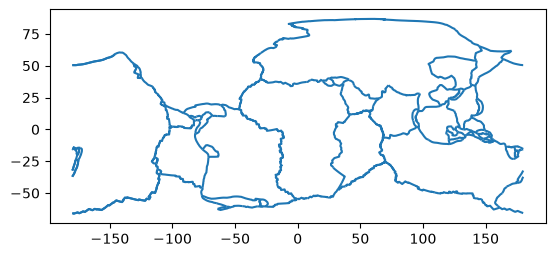

In [3]:
plate_bound = gpd.read_file('..\\data\\tectonicplates-master\\tectonicplates-master\\PB2002_boundaries.shp')
plate_bound.plot()

In [43]:
print(np.where(plate_bound['PlateA']=='JF'))

(array([67]),)


looking for jdf points

| is the 'or' for arrays

passing the true/false series into [] filters the dataframe to values w true

In [49]:
print(plate_bound[(plate_bound['PlateA'] == 'JF') | (plate_bound['PlateB'] == 'JF')])

             LAYER   Name                                            Source  \
66  plate boundary  PA-JF  Mueller et al. [1987]; N end by Peter Bird, 1999   
67  plate boundary  JF\NA                               by Peter Bird, 1999   

   PlateA PlateB        Type  \
66     PA     JF         NaN   
67     JF     NA  subduction   

                                             geometry  
66  LINESTRING (-124.742 40.3134, -125.45 40.3541,...  
67  LINESTRING (-124.742 40.3134, -124.953 40.6333...  


### downloading asf

for the entire dataset

In [ ]:
# dg.to_csv("..\\created_data\\lola_grav_age_q_z_bath.csv", index=False)

for test/train data split

In [ ]:
# # train_filt_dg = dg[dg['long'].between(-130, -128) & dg['lat'].between(44, 46)]
# # test_filt_dg = dg[dg['long'].between(-130, -128) & dg['lat'].between(46, 48)]

# train_filt_dg.to_csv("..\\created_data\\train_filt_lola_grav_age_q_z_bath.csv", index=False)
# test_filt_dg.to_csv("..\\created_data\\test_filt_lola_grav_age_q_z_bath.csv", index=False)

for filt data

In [21]:
filt_dg = dg[dg['long'].between(-129, -127) & dg['lat'].between(45, 47)]

filt_dg.to_csv("..\\created_data\\filt_lola_grav_age_q_z_bath.csv", index=False)